<a href="https://colab.research.google.com/github/MrT4ttoo/GestionInformacion/blob/main/DemoInvestigaci%C3%B3n_WebScrapingEtico_LaPrensa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗞️ Web Scraping Ético — La Prensa Panamá
**Gestión de la Información · UTP 2026 · Grupo 1SF241**

| | |
|---|---|
| **Fuente** | La Prensa Panamá — Sitemap público de noticias |
| **Marco ético** | Ley 81 de Panamá · Robots Exclusion Protocol · Minimización de datos |
| **Herramientas** | `requests` · `BeautifulSoup` · `pandas` · `matplotlib` |
| **Salidas** | `la_prensa_noticias.csv` · 3 gráficos · resumen estadístico |

> **Instrucción:** Ejecuta las celdas en orden (`Shift+Enter`). Si el scraper falla (red o estructura), el **Plan B** carga un dataset de respaldo para continuar sin interrupciones.


---
## ⚙️ Paso 0 — Instalación de dependencias
Solo necesario en Colab.

In [ ]:
!pip install requests beautifulsoup4 lxml --quiet
print('✅ Dependencias instaladas')

---
## 📦 Paso 1 — Importaciones y configuración global

In [1]:
import re
import time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlparse
from urllib.robotparser import RobotFileParser

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'figure.dpi'       : 120,
})

COLOR_PRIMARY   = '#01696f'
COLOR_SECONDARY = '#4f98a3'
COLOR_ACCENT    = '#964219'
COLOR_LIGHT     = '#cedcd8'

BASE_URL    = 'https://www.prensa.com'
ROBOTS_URL  = f'{BASE_URL}/robots.txt'
SITEMAP_URL = f'{BASE_URL}/arc/outboundfeeds/news-sitemap/?outputType=xml'
USER_AGENT  = (
    'UTP-GestionInfo-WebScraping/1.0 '
    '(Proyecto academico; contacto: ejemplo@utp.ac.pa)'
)

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

STOPWORDS = {
    'a','al','ante','como','con','de','del','e','el','en','es','esta',
    'este','ha','han','las','lo','los','la','más','no','o','para',
    'pero','por','que','se','sin','sobre','son','su','sus','un','una','y'
}

CATEGORY_LABELS = {
    'politica':'Política','economia':'Economía','deportes':'Deportes',
    'mundo':'Mundo','vivir':'Vivir','opinion':'Opinión',
    'judiciales':'Judiciales','locales':'Locales','sociedad':'Sociedad',
}

print('✅ Configuración lista')

✅ Configuración lista


---
## 🤖 Paso 2 — Verificación ética: `robots.txt`

> Revisamos qué rutas nos permite consultar el sitio antes de hacer cualquier petición. Principio de **licitud** (Ley 81 de Panamá).


In [2]:
def verificar_robots(url_objetivo: str) -> bool:
    parser = RobotFileParser()
    parser.set_url(ROBOTS_URL)
    try:
        parser.read()
        return parser.can_fetch(USER_AGENT, url_objetivo)
    except Exception as e:
        print(f'[ADVERTENCIA] No se pudo leer robots.txt: {e}')
        return True

for url in [SITEMAP_URL, f'{BASE_URL}/locales/']:
    ok = verificar_robots(url)
    print(f'{"✅ PERMITIDO" if ok else "🚫 BLOQUEADO"} → {url}')

✅ PERMITIDO → https://www.prensa.com/arc/outboundfeeds/news-sitemap/?outputType=xml
✅ PERMITIDO → https://www.prensa.com/locales/


---
## 🕷️ Paso 3 — Scraper principal (vía Sitemap XML)

Usamos el **sitemap público** declarado en `robots.txt`. Es la forma más ética y estable: no accedemos a rutas bloqueadas ni copiamos contenido completo de artículos.


In [3]:
def crear_sesion():
    s = requests.Session()
    s.headers['User-Agent'] = USER_AGENT
    return s

def categoria_desde_url(url):
    slug = urlparse(url).path.strip('/').split('/', 1)[0]
    return CATEGORY_LABELS.get(slug, slug.replace('-', ' ').title() or 'Sin categoría')

def texto_tag(parent, *nombres):
    wanted = {n.lower() for n in nombres}
    for tag in parent.find_all(True):
        local = str(tag.name).lower().split(':')[-1]
        if str(tag.name).lower() in wanted or local in wanted:
            txt = tag.get_text(' ', strip=True)
            if txt:
                return txt
    return ''

def parsear_sitemap(xml, limite=50):
    soup = BeautifulSoup(xml, 'lxml-xml')
    extraido_en = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    noticias = []
    for node in soup.find_all('url'):
        loc = texto_tag(node, 'loc')
        if not loc:
            continue
        titulo = texto_tag(node, 'news:title', 'title')
        if not titulo:
            continue
        fecha = texto_tag(node, 'news:publication_date', 'publication_date', 'lastmod')
        noticias.append({
            'titulo'      : titulo,
            'url'         : loc,
            'fecha'       : fecha,
            'categoria'   : categoria_desde_url(loc),
            'fuente'      : 'La Prensa Panamá',
            'extraido_en' : extraido_en,
        })
        if len(noticias) >= limite:
            break
    return noticias

print('✅ Funciones del scraper definidas')

✅ Funciones del scraper definidas


In [4]:
LIMITE = 50  # ← Cambia este número para extraer más o menos noticias

print(f'[INFO] Descargando sitemap desde:\n  {SITEMAP_URL}')
session = crear_sesion()
noticias = []

try:
    r = session.get(SITEMAP_URL, timeout=20)
    r.raise_for_status()
    time.sleep(1)  # Pausa respetuosa entre peticiones
    noticias = parsear_sitemap(r.text, limite=LIMITE)
    print(f'[INFO] Noticias extraídas: {len(noticias)}')
except Exception as e:
    print(f'[ERROR] {e}')
    print('[INFO] Ejecuta la celda del Plan B para continuar.')

if noticias:
    df = pd.DataFrame(noticias)
    df.to_csv('la_prensa_noticias.csv', index=False, encoding='utf-8')
    print('[INFO] Dataset guardado → la_prensa_noticias.csv')
    print('\n📋 Vista previa:')
    display(df.head(8))
else:
    df = None
    print('[ADVERTENCIA] Sin noticias. Usa el Plan B.')

[INFO] Descargando sitemap desde:
  https://www.prensa.com/arc/outboundfeeds/news-sitemap/?outputType=xml
[INFO] Noticias extraídas: 50
[INFO] Dataset guardado → la_prensa_noticias.csv

📋 Vista previa:


,titulo,url,fecha,categoria,fuente,extraido_en
0,La Asep advierte sobre la venta de dispositivo...,https://www.prensa.com/economia/la-asep-advier...,2026-05-14T00:29:53.846Z,Economía,La Prensa Panamá,2026-05-14 00:35:22 UTC
1,Rafa Nadal niega cualquier relación con candid...,https://www.prensa.com/deportes/rafa-nadal-nie...,2026-05-14T00:09:00.242Z,Deportes,La Prensa Panamá,2026-05-14 00:35:22 UTC
2,Otra renuncia en el agro: gerente del ISA se s...,https://www.prensa.com/politica/otra-renuncia-...,2026-05-13T23:22:06.053Z,Política,La Prensa Panamá,2026-05-14 00:35:22 UTC
3,Demandan facultad de Contraloría para aplicar ...,https://www.prensa.com/judiciales/demandan-fac...,2026-05-13T22:53:19.091Z,Judiciales,La Prensa Panamá,2026-05-14 00:35:22 UTC
4,Quién es Enrique Riquelme: El adversario de Fl...,https://www.prensa.com/deportes/quien-es-enriq...,2026-05-13T22:39:07.574Z,Deportes,La Prensa Panamá,2026-05-14 00:35:22 UTC
5,Felipe Baloy anunció la convocatoria para el t...,https://www.prensa.com/deportes/felipe-baloy-a...,2026-05-13T22:38:53.323Z,Deportes,La Prensa Panamá,2026-05-14 00:35:22 UTC
6,"Condenan en Estados Unidos a ‘Doña Lupe’, por ...",https://www.prensa.com/mundo/condenan-en-estad...,2026-05-13T22:35:30.649Z,Mundo,La Prensa Panamá,2026-05-14 00:35:22 UTC
7,Contralor Anel Flores no acude a conferencia y...,https://www.prensa.com/politica/contralor-anel...,2026-05-13T22:33:42.873Z,Política,La Prensa Panamá,2026-05-14 00:35:22 UTC


---
## 🆘 Plan B — Dataset de respaldo

> **Solo ejecuta esta celda si el scraper devolvió 0 noticias o dio error.** Carga 20 registros representativos para que el análisis funcione sin interrupciones.


In [ ]:
# ─────────────────────────────────────────────────────────────
# PLAN B — Solo ejecutar si el scraper principal falló
# ─────────────────────────────────────────────────────────────

datos_respaldo = [
    {'titulo':'Asamblea aprueba ajuste al presupuesto nacional 2026','url':'https://www.prensa.com/politica/asamblea-presupuesto/','fecha':'2026-05-12','categoria':'Política','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Minsa anuncia nueva campaña de vacunación en todo el país','url':'https://www.prensa.com/locales/minsa-vacunacion/','fecha':'2026-05-12','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Municipio de Panamá lanza plan de rehabilitación vial','url':'https://www.prensa.com/locales/municipio-vial/','fecha':'2026-05-12','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Metro de Panamá aumenta frecuencia en hora pico','url':'https://www.prensa.com/locales/metro-frecuencia/','fecha':'2026-05-11','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'UTP presenta proyecto de innovación en energías renovables','url':'https://www.prensa.com/locales/utp-energia/','fecha':'2026-05-11','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Autoridad de Turismo reporta aumento de visitantes en mayo','url':'https://www.prensa.com/economia/turismo-mayo/','fecha':'2026-05-11','categoria':'Economía','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'CSS inicia proceso de digitalización de expedientes médicos','url':'https://www.prensa.com/locales/css-digital/','fecha':'2026-05-10','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Conapredes alerta sobre inicio de temporada lluviosa','url':'https://www.prensa.com/locales/conapredes-lluvias/','fecha':'2026-05-10','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Banco Nacional lanza crédito para pequeños productores','url':'https://www.prensa.com/economia/banco-credito/','fecha':'2026-05-10','categoria':'Economía','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Panamá firma acuerdo de cooperación en ciberseguridad','url':'https://www.prensa.com/politica/ciberseguridad/','fecha':'2026-05-09','categoria':'Política','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Miviot anuncia entrega de 500 viviendas en Arraiján','url':'https://www.prensa.com/locales/miviot-arraijan/','fecha':'2026-05-09','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'ACP reporta tráfico récord de naves en el Canal durante abril','url':'https://www.prensa.com/economia/acp-record/','fecha':'2026-05-09','categoria':'Economía','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Defensoría del Pueblo recibe más de 300 quejas en primer trimestre','url':'https://www.prensa.com/judiciales/defensoria-quejas/','fecha':'2026-05-08','categoria':'Judiciales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Selección de fútbol clasifica para siguiente ronda de eliminatorias','url':'https://www.prensa.com/deportes/seleccion-clasifica/','fecha':'2026-05-08','categoria':'Deportes','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'ETESA reporta lluvias intensas en provincias centrales','url':'https://www.prensa.com/locales/etesa-lluvias/','fecha':'2026-05-08','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Ministerio de Educación lanza programa de becas tecnológicas','url':'https://www.prensa.com/locales/meduca-becas/','fecha':'2026-05-07','categoria':'Locales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Bolsa de valores de Panamá cierra semana con alzas moderadas','url':'https://www.prensa.com/economia/bolsa-alzas/','fecha':'2026-05-07','categoria':'Economía','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Policía Nacional desmantela red de tráfico de mercancía ilegal','url':'https://www.prensa.com/judiciales/policia-trafico/','fecha':'2026-05-07','categoria':'Judiciales','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Hidroeléctrica Bayano aumenta producción ante temporada seca','url':'https://www.prensa.com/economia/bayano-produccion/','fecha':'2026-05-06','categoria':'Economía','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
    {'titulo':'Conferencia regional de ciberseguridad se celebra en Ciudad de Panamá','url':'https://www.prensa.com/mundo/conferencia-ciber/','fecha':'2026-05-06','categoria':'Mundo','fuente':'La Prensa Panamá','extraido_en':'2026-05-12 20:00:00 UTC'},
]

df = pd.DataFrame(datos_respaldo)
df.to_csv('la_prensa_noticias.csv', index=False, encoding='utf-8')
print(f'✅ Plan B activo — {len(df)} noticias de respaldo cargadas')
display(df)

---
## 📊 Paso 4 — Análisis exploratorio

Métricas clave para **Gestión de la Información**: volumen, cobertura, distribución por categoría y fecha, longitud de titulares.


In [5]:
df = pd.read_csv('la_prensa_noticias.csv')

df['fecha_norm'] = pd.to_datetime(df['fecha'], errors='coerce', utc=True)
df['fecha_dia']  = df['fecha_norm'].dt.date
df['longitud_titulo'] = df['titulo'].astype(str).str.len()

print('=' * 55)
print('📋  RESUMEN DEL DATASET — La Prensa Panamá')
print('=' * 55)
print(f'  Total de noticias         : {len(df)}')
print(f'  Noticias con fecha válida : {df["fecha_norm"].notna().sum()}')
print(f'  Categorías únicas         : {df["categoria"].nunique()}')
print(f'  Días cubiertos            : {df["fecha_dia"].nunique()}')
print(f'\n📏  LONGITUD DE TITULARES')
print(f'  Promedio : {df["longitud_titulo"].mean():.1f} chars')
print(f'  Mínimo   : {df["longitud_titulo"].min()} chars')
print(f'  Máximo   : {df["longitud_titulo"].max()} chars')
print(f'\n📂  NOTICIAS POR CATEGORÍA')
print(df['categoria'].value_counts().to_string())

📋  RESUMEN DEL DATASET — La Prensa Panamá
  Total de noticias         : 50
  Noticias con fecha válida : 50
  Categorías únicas         : 10
  Días cubiertos            : 2

📏  LONGITUD DE TITULARES
  Promedio : 79.9 chars
  Mínimo   : 8 chars
  Máximo   : 125 chars

📂  NOTICIAS POR CATEGORÍA
categoria
Economía      16
Deportes       8
Mundo          7
Política       6
Judiciales     4
Sociedad       4
Bbc            2
Cerokm         1
Loterias       1
Opinión        1


---
## 📈 Paso 5 — Visualizaciones

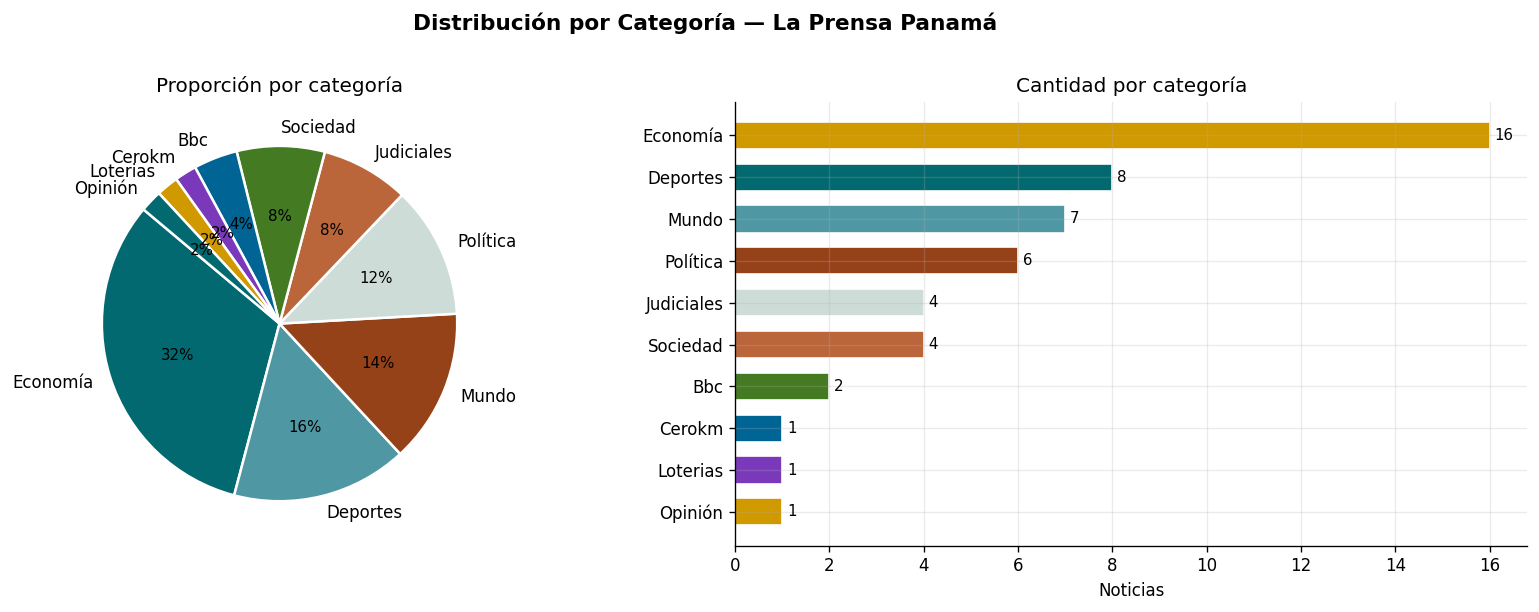

✅ Gráfico 1 guardado → output/grafico_categorias.png


In [6]:
# ── Gráfico 1: Distribución por categoría
conteo_cat = df['categoria'].value_counts()
colores = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_LIGHT,
           '#bb653b', '#437a22', '#006494', '#7a39bb', '#d19900'][:len(conteo_cat)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución por Categoría — La Prensa Panamá',
             fontsize=13, fontweight='bold', y=1.01)

wedges, texts, autotexts = ax1.pie(
    conteo_cat.values, labels=conteo_cat.index, colors=colores,
    autopct='%1.0f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
ax1.set_title('Proporción por categoría')

bars = ax2.barh(conteo_cat.index[::-1], conteo_cat.values[::-1],
                color=colores[::-1], edgecolor='white', height=0.65)
for bar in bars:
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontsize=9)
ax2.set_xlabel('Noticias')
ax2.set_title('Cantidad por categoría')

plt.tight_layout()
plt.savefig('output/grafico_categorias.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico 1 guardado → output/grafico_categorias.png')

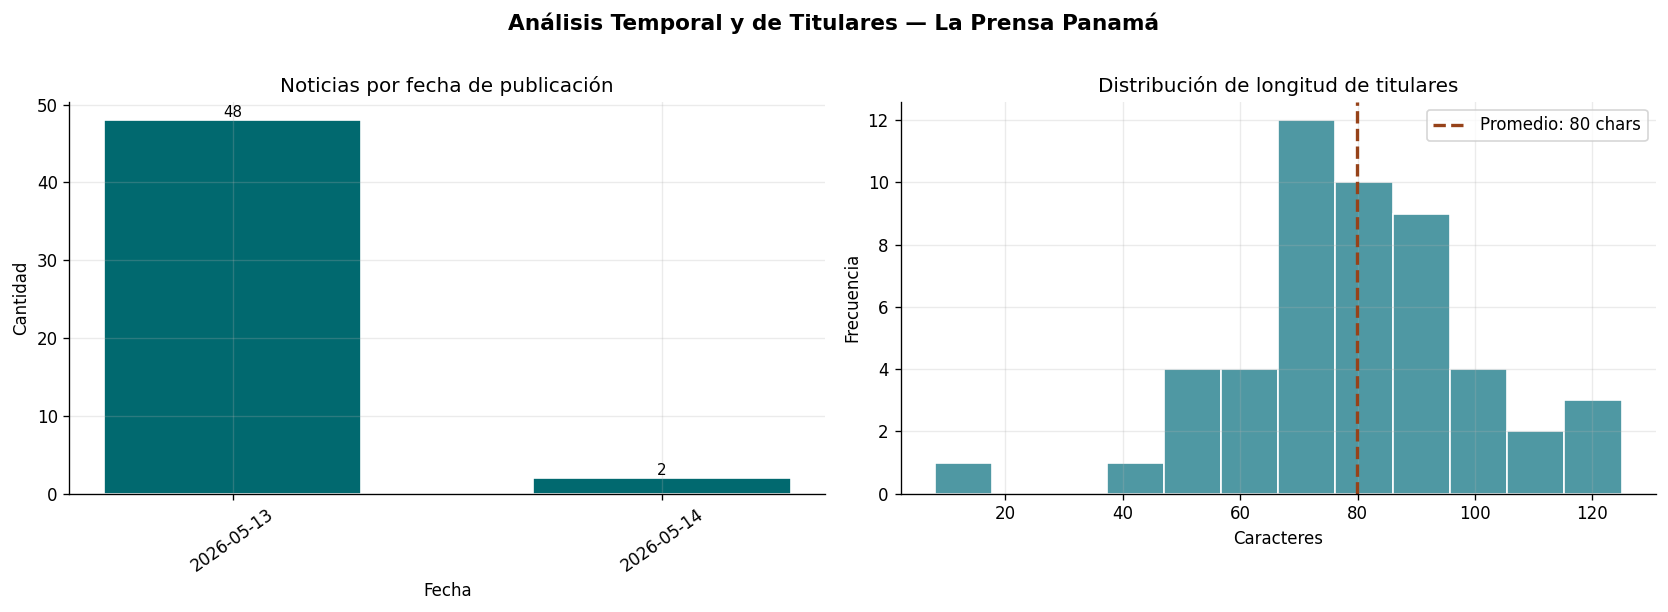

✅ Gráfico 2 guardado → output/grafico_temporal_longitud.png


In [7]:
# ── Gráfico 2: Noticias por fecha + histograma de longitud
conteo_fechas = df.groupby('fecha_dia').size().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis Temporal y de Titulares — La Prensa Panamá',
             fontsize=13, fontweight='bold', y=1.01)

if not conteo_fechas.empty:
    ax1.bar([str(f) for f in conteo_fechas.index], conteo_fechas.values,
            color=COLOR_PRIMARY, edgecolor='white', width=0.6)
    ax1.set_title('Noticias por fecha de publicación')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Cantidad')
    ax1.tick_params(axis='x', rotation=35)
    for i, v in enumerate(conteo_fechas.values):
        ax1.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'Fechas no disponibles', ha='center', va='center', fontsize=12)

media = df['longitud_titulo'].mean()
ax2.hist(df['longitud_titulo'], bins=12, color=COLOR_SECONDARY, edgecolor='white')
ax2.axvline(media, color=COLOR_ACCENT, linestyle='--', linewidth=2,
            label=f'Promedio: {media:.0f} chars')
ax2.set_title('Distribución de longitud de titulares')
ax2.set_xlabel('Caracteres')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.tight_layout()
plt.savefig('output/grafico_temporal_longitud.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico 2 guardado → output/grafico_temporal_longitud.png')

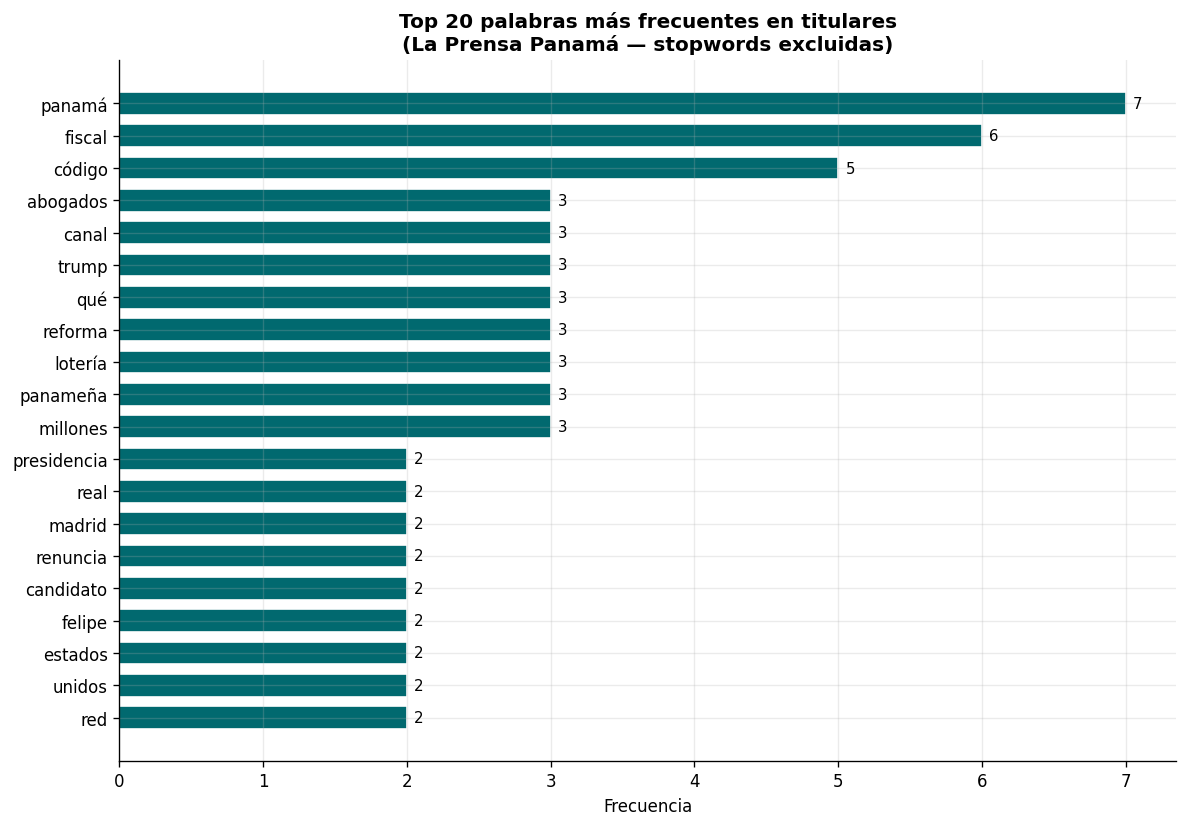

✅ Gráfico 3 guardado → output/grafico_palabras.png


In [8]:
# ── Gráfico 3: Top 20 palabras más frecuentes en titulares
texto_completo = ' '.join(df['titulo'].astype(str)).lower()
palabras = re.findall(r'[a-záéíóúüñ]+', texto_completo)
filtradas = [p for p in palabras if p not in STOPWORDS and len(p) > 2]
top20 = Counter(filtradas).most_common(20)

if top20:
    palabras_top, frecuencias = zip(*top20)
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(palabras_top[::-1], frecuencias[::-1],
                   color=COLOR_PRIMARY, edgecolor='white', height=0.7)
    for bar, val in zip(bars, frecuencias[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_title('Top 20 palabras más frecuentes en titulares\n'
                 '(La Prensa Panamá — stopwords excluidas)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    plt.tight_layout()
    plt.savefig('output/grafico_palabras.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Gráfico 3 guardado → output/grafico_palabras.png')

---
## 💾 Paso 6 — Exportar resumen estadístico

In [9]:
top_palabra, top_freq = top20[0] if top20 else ('N/A', 0)

resumen = pd.DataFrame([{
    'total_noticias'          : len(df),
    'noticias_con_fecha'      : int(df['fecha_norm'].notna().sum()),
    'categorias_unicas'       : int(df['categoria'].nunique()),
    'dias_cubiertos'          : int(df['fecha_dia'].nunique()),
    'longitud_media_titulo'   : round(df['longitud_titulo'].mean(), 2),
    'longitud_min_titulo'     : int(df['longitud_titulo'].min()),
    'longitud_max_titulo'     : int(df['longitud_titulo'].max()),
    'palabra_mas_comun'       : top_palabra,
    'frecuencia_top_palabra'  : top_freq,
    'fecha_analisis'          : datetime.now(timezone.utc).strftime('%Y-%m-%d'),
}])

resumen.to_csv('output/resumen_estadistico.csv', index=False)
print('\n📊 RESUMEN ESTADÍSTICO FINAL')
display(resumen.T.rename(columns={0: 'Valor'}))
print('\n✅ Archivos generados:')
print('   • la_prensa_noticias.csv                  → dataset completo')
print('   • output/grafico_categorias.png           → distribución por categoría')
print('   • output/grafico_temporal_longitud.png    → fechas y longitud')
print('   • output/grafico_palabras.png             → top 20 palabras')
print('   • output/resumen_estadistico.csv          → métricas del dataset')


📊 RESUMEN ESTADÍSTICO FINAL


,Valor
total_noticias,50
noticias_con_fecha,50
categorias_unicas,10
dias_cubiertos,2
longitud_media_titulo,79.92
longitud_min_titulo,8
longitud_max_titulo,125
palabra_mas_comun,panamá
frecuencia_top_palabra,7
fecha_analisis,2026-05-14



✅ Archivos generados:
   • la_prensa_noticias.csv                  → dataset completo
   • output/grafico_categorias.png           → distribución por categoría
   • output/grafico_temporal_longitud.png    → fechas y longitud
   • output/grafico_palabras.png             → top 20 palabras
   • output/resumen_estadistico.csv          → métricas del dataset


---
## ✅ Conclusión del caso de estudio

Este notebook demostró un flujo completo de **web scraping ético** aplicado a un medio panameño real:

| Etapa | Acción | Principio ético aplicado |
|---|---|---|
| Verificación previa | Revisión de `robots.txt` | Respeto a las reglas del sitio |
| Extracción | Sitemap XML público · `User-Agent` identificable · pausa de 1 s | Transparencia · no saturar servidor |
| Alcance | Solo metadatos públicos (titular, fecha, URL, categoría) | Minimización de datos |
| Almacenamiento | CSV local, sin datos personales | Proporcionalidad y seguridad |
| Análisis | Estadísticas agregadas, sin reidentificación | Finalidad académica declarada |

> **Grupo 1SF241 — Gestión de la Información, UTP 2026**  
> Aldo Apicella · Yamar Camarena · Carlos Delgado · Adolfo López
